Argentine Inflation Tracker: High-Frequency Price Monitoring
Project Overview: > This project aims to monitor inflation in Argentina by scraping real-time price data from major retailers. Given the country's inflationary context, high-frequency data collection is essential for understanding price dynamics beyond official monthly reports.

Methodology: > * Data Source: Carrefour Argentina (Almacén/Grocery section).

Frequency: Weekly captures to calculate WoW (Week-over-Week) variation.

Status:  In Development - Phase 1: Data Collection & Storage.

In [3]:
pip install selenium webdriver-manager

   ---------------------------------------- 0.0/9.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.5 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.5 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.5 MB ? eta -:--:--
   -- ------------------------------------- 0.5/9.5 MB 526.0 kB/s eta 0:00:18
   -- ------------------------------------- 0.5/9.5 MB 526.0 kB/s eta 0:00:18
   --- ------------------------------------ 0.8/9.5 MB 569.1 kB/s eta 0:00:16
   --- ------------------------------------ 0.8/9.5 MB 569.1 kB/s eta 0:00:16
   ---- ----------------------------------- 1.0/9.5 MB 629.0 kB/s eta 0:00:14
   ---- ----------------------------------- 1.0/9.5 MB 629.0 kB/s eta 0:00:14
   ----- ---------------------------------- 1.3/9.5 MB 636.1 kB/s eta 0:00:13
   ----- ---------------------------------- 1.3/9.5 MB 636.1 kB/s eta 0:00:13
   ------ ---------------------

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\agusm\AppData\Local\Python\pythoncore-3.14-64\python.exe -m pip install --upgrade pip


In [ ]:
import requests
import pandas as pd
from datetime import datetime
import time

def fetch_carrefour_almacen():
    
    url = "https://www.carrefour.com.ar/api/catalog_system/pub/products/search/almacen"
    
    
    params = {
        "_from": 0,
        "_to": 49,
        "O": "OrderByTopSaleDESC"
    }

    headers = {
        "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36",
        "Accept": "application/json"
    }

    try:
        print(f"[{datetime.now().strftime('%H:%M:%S')}] Conectando con Carrefour...")
        response = requests.get(url, params=params, headers=headers, timeout=15)
        response.raise_for_status()
        
        products_json = response.json()
        product_list = []
        
        for item in products_json:
            
            item_data = item['items'][0]
            commertial_offer = item_data['sellers'][0]['commertialOffer']
            
            
            reference_price = "N/A"
            
            
            all_specs = item.get('allSpecifications', [])
            for spec_name in all_specs:
                if 'unidad de medida' in spec_name.lower():
                    spec_values = item.get(spec_name)
                    if spec_values:
                        reference_price = spec_values[0]
                        break
            
            
            if reference_price == "N/A":
                unit = item_data.get('measurementUnit', '')
                multiplier = item_data.get('unitMultiplier', 1)
                if unit:
                    reference_price = f"{multiplier} {unit}"

            
            product_info = {
                "Fecha": datetime.now().strftime('%Y-%m-%d'),
                "Producto": item.get('productName'),
                "Marca": item.get('brand'),
                "Precio_Actual": commertial_offer.get('Price'),
                "Precio_Lista": commertial_offer.get('ListPrice'),
                "Unidad_Ref": reference_price,
                "Link": item.get('link')
            }
            product_list.append(product_info)
        
        
        df = pd.DataFrame(product_list)
        return df

    except Exception as e:
        print(f"Error detectado: {e}")
        return None

if __name__ == "__main__":
    df_results = fetch_carrefour_almacen()
    
    if df_results is not None and not df_results.empty:
        print("\n¡Datos recuperados con éxito!")
        print(df_results[['Producto', 'Precio_Actual', 'Unidad_Ref']].head())
        
        
        nombre_archivo = f"precios_almacen_{datetime.now().strftime('%Y%m%d')}.csv"
        df_results.to_csv(nombre_archivo, index=False, encoding='utf-8-sig')
        print(f"\nArchivo guardado: {nombre_archivo}")
    else:
        print("No se pudieron obtener datos. Verificá la conexión.")

[13:17:51] Conectando con Carrefour...

¡Datos recuperados con éxito!
                                            Producto  Precio_Actual Unidad_Ref
0        Lomitos de atún Carrefour al natural 170 g.        2934.80        GRM
1                   Puré de tomate Arcor brik 520 g.         719.00        GRM
2                Fideos tallarin N5 Lucchetti 500 g.        1499.00        GRM
3              Fideos tirabuzon N28 Lucchetti 500 g.        1499.00        GRM
4  Mayonesa Clásica Hellmanns sin tacc doypack 47...        2099.25        GRM

Archivo guardado: precios_almacen_20260308.csv


In [ ]:
import requests
import pandas as pd
from datetime import datetime
import time

def scrape_carrefour_inflacion(paginas=5):
    all_products = []
    headers = {
        "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36"
    }
    
    print(f"[{datetime.now().strftime('%H:%M:%S')}] Iniciando relevamiento de Almacén...")

    for p in range(paginas):
        start = p * 50
        end = start + 49
        url = f"https://www.carrefour.com.ar/api/catalog_system/pub/products/search/almacen?_from={start}&_to={end}&O=OrderByTopSaleDESC"
        
        try:
            res = requests.get(url, headers=headers, timeout=15)
            res.raise_for_status()
            data = res.json()
            
            if not data:
                break

            for item in data:
                item_data = item['items'][0]
                commertial_offer = item_data['sellers'][0]['commertialOffer']
                
                
                unit = item_data.get('measurementUnit', 'un')
                if unit == 'GRM': unit = 'g'
                if unit == 'MLT': unit = 'ml'
                if unit == 'KGM': unit = 'kg'

                all_products.append({
                    "Fecha": datetime.now().strftime('%Y-%m-%d'),
                    "Producto": item.get('productName'),
                    "Marca": item.get('brand'),
                    "Precio": commertial_offer.get('Price'),
                    "Unidad": f"{item_data.get('unitMultiplier', 1)} {unit}",
                    "Categoria": "Almacen"
                })
            
            print(f" > Página {p+1} procesada ({len(all_products)} productos acumulados)")
            time.sleep(1) 

        except Exception as e:
            print(f" Error en página {p+1}: {e}")
            break

    return pd.DataFrame(all_products)


df_final = scrape_carrefour_inflacion(paginas=5) 

if not df_final.empty:
    filename = f"canasta_carrefour_{datetime.now().strftime('%Y%m%d')}.csv"
    df_final.to_csv(filename, index=False, encoding='utf-8-sig')
    print(f"\n¡Listo! Se guardaron {len(df_final)} productos en {filename}")
    print(df_final.head())

[13:19:11] Iniciando relevamiento de Almacén...
 > Página 1 procesada (50 productos acumulados)
 > Página 2 procesada (100 productos acumulados)
 > Página 3 procesada (150 productos acumulados)
 > Página 4 procesada (200 productos acumulados)
 > Página 5 procesada (250 productos acumulados)

¡Listo! Se guardaron 250 productos en canasta_carrefour_20260308.csv
        Fecha                                           Producto      Marca  \
0  2026-03-08        Lomitos de atún Carrefour al natural 170 g.  Carrefour   
1  2026-03-08                   Puré de tomate Arcor brik 520 g.      Arcor   
2  2026-03-08                Fideos tallarin N5 Lucchetti 500 g.  Matarazzo   
3  2026-03-08              Fideos tirabuzon N28 Lucchetti 500 g.   Luchetti   
4  2026-03-08  Mayonesa Clásica Hellmanns sin tacc doypack 47...  Hellmanns   

    Precio  Unidad Categoria  
0  2934.80  1.0 un   Almacen  
1   719.00  1.0 un   Almacen  
2  1499.00  1.0 un   Almacen  
3  1499.00  1.0 un   Almacen  
4  2099.

UPDATE 3/15/2026

In [ ]:
import requests
import pandas as pd
from datetime import datetime
import time

def scrape_carrefour_inflacion(paginas=5):
    all_products = []
    headers = {
        "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36"
    }
    
    print(f"[{datetime.now().strftime('%H:%M:%S')}] Iniciando relevamiento de Almacén...")

    for p in range(paginas):
        
        start = p * 50
        end = start + 49
        url = f"https://www.carrefour.com.ar/api/catalog_system/pub/products/search/almacen?_from={start}&_to={end}&O=OrderByTopSaleDESC"
        
        try:
            res = requests.get(url, headers=headers, timeout=15)
            res.raise_for_status()
            data = res.json()
            
            if not data:
                break

            for item in data:
                item_data = item['items'][0]
                commertial_offer = item_data['sellers'][0]['commertialOffer']
                
                
                unit = item_data.get('measurementUnit', 'un')
                if unit == 'GRM': unit = 'g'
                if unit == 'MLT': unit = 'ml'
                if unit == 'KGM': unit = 'kg'

                all_products.append({
                    "Fecha": datetime.now().strftime('%Y-%m-%d'),
                    "Producto": item.get('productName'),
                    "Marca": item.get('brand'),
                    "Precio_S2": commertial_offer.get('Price'), 
                    "Unidad": f"{item_data.get('unitMultiplier', 1)} {unit}"
                })
            
            print(f" > Página {p+1} procesada ({len(all_products)} productos acumulados)")
            time.sleep(1.5) 

        except Exception as e:
            print(f" Error en página {p+1}: {e}")
            break

    return pd.DataFrame(all_products)


df_hoy = scrape_carrefour_inflacion(paginas=5) 

if not df_hoy.empty:
    
    filename = f"precios_almacen_{datetime.now().strftime('%Y%m%d')}.csv"
    df_hoy.to_csv(filename, index=False, encoding='utf-8-sig')
    print(f"\n¡Listo! Archivo guardado como: {filename}")
else:
    print("No se pudieron obtener datos.")

[11:19:27] Iniciando relevamiento de Almacén...
 > Página 1 procesada (50 productos acumulados)
 > Página 2 procesada (100 productos acumulados)
 > Página 3 procesada (150 productos acumulados)
 > Página 4 procesada (200 productos acumulados)
 > Página 5 procesada (250 productos acumulados)

¡Listo! Archivo guardado como: precios_almacen_20260315.csv


Comparison between the previous week and this one:

In [ ]:
import pandas as pd


df_viejos = pd.read_csv("precios_almacen_20260308.csv")
df_nuevos = pd.read_csv("precios_almacen_20260315.csv")


df_final = pd.merge(df_viejos, df_nuevos, on=["Producto", "Marca"], suffixes=('_Semana1', '_Semana2'))


df_final['Variacion_Semanas_%'] = ((df_final['Precio_S2'] / df_final['Precio_Actual']) - 1) * 100


inflacion_canasta = df_final['Variacion_Semanas_%'].mean()

print(f"--- REPORTE DE INFLACIÓN SEMANAL - UBA ---")
print(f"Productos comparados con éxito: {len(df_final)}")
print(f"Inflación promedio de la semana: {inflacion_canasta:.2f}%")


df_final.to_csv("reporte_comparativo_final.csv", index=False, encoding='utf-8-sig')
print("\n¡Reporte guardado como 'reporte_comparativo_final.csv'!")

--- REPORTE DE INFLACIÓN SEMANAL - UBA ---
Productos comparados con éxito: 50
Inflación promedio de la semana: 2.07%

¡Reporte guardado como 'reporte_comparativo_final.csv'!


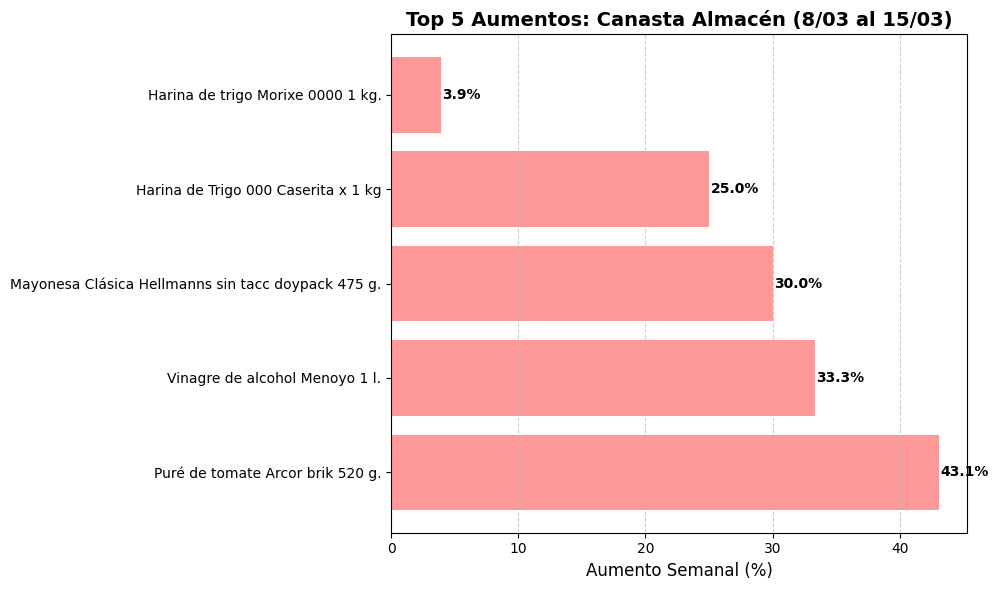

In [3]:
import pandas as pd
import matplotlib.pyplot as plt


df_reporte = pd.read_csv("reporte_comparativo_final.csv")


top_5 = df_reporte.sort_values(by='Variacion_Semanas_%', ascending=False).head(5)


plt.figure(figsize=(10, 6))
plt.barh(top_5['Producto'], top_5['Variacion_Semanas_%'], color='#ff9999')


plt.xlabel('Aumento Semanal (%)', fontsize=12)
plt.title('Top 5 Aumentos: Canasta Almacén (8/03 al 15/03)', fontsize=14, fontweight='bold')
plt.grid(axis='x', linestyle='--', alpha=0.6)


for i, v in enumerate(top_5['Variacion_Semanas_%']):
    plt.text(v + 0.1, i, f"{v:.1f}%", color='black', va='center', fontweight='bold')

plt.tight_layout()
plt.show()

This project tracks weekly inflation for the 'Almacén' (Grocery) category at Carrefour Argentina using an automated API-based scraping approach. By comparing a consistent sample of 50 products between March 8 and March 15, the analysis revealed a weekly inflation rate of 2.07%. While the average remains relatively stable, the data shows high price dispersion, with specific items (such as tomato purée and condiments) recording spikes of over 30% following the expiration of seasonal promotions. This high-frequency monitoring method is essential for capturing inflationary dynamics that standard monthly CPI reports might smooth over.

NEXT UPDATE 3/22/2026